In [25]:
# ============================================================
# 1. INSTALĀCIJA AR FIKSĒTĀM VERSIJĀM
# ============================================================

!pip install \
    stanza==1.12.0 \
    scikit-learn==1.6.1 \
    pandas==2.2.2 \
    numpy==2.0.2 \
    matplotlib==3.10.0 \
    seaborn==0.13.2 \
    openpyxl==3.1.5 \
    --quiet

In [26]:
# ============================================================
# 1A. VIDES VERSIJU PĀRBAUDE
# ============================================================

import sys
import platform
import stanza
import sklearn
import pandas as pd
import numpy as np
import matplotlib
import seaborn
import openpyxl

print("Python:", sys.version)
print("Platform:", platform.platform())
print("stanza:", stanza.__version__)
print("scikit-learn:", sklearn.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)
print("openpyxl:", openpyxl.__version__)

REQUIRED_VERSIONS = {
    "stanza": "1.12.0",
    "scikit-learn": "1.6.1",
    "pandas": "2.2.2",
    "numpy": "2.0.2",
    "matplotlib": "3.10.0",
    "seaborn": "0.13.2",
    "openpyxl": "3.1.5",
}

CURRENT_VERSIONS = {
    "stanza": stanza.__version__,
    "scikit-learn": sklearn.__version__,
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": seaborn.__version__,
    "openpyxl": openpyxl.__version__,
}

for package, required_version in REQUIRED_VERSIONS.items():
    current_version = CURRENT_VERSIONS[package]
    if current_version != required_version:
        raise RuntimeError(
            f"Versiju nesakritība: {package} == {current_version}, "
            f"bet nepieciešams {required_version}"
        )

print("✓ Visas bibliotēku versijas atbilst reproducējamajai videi.")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
stanza: 1.12.0
scikit-learn: 1.6.1
pandas: 2.2.2
numpy: 2.0.2
matplotlib: 3.10.0
seaborn: 0.13.2
openpyxl: 3.1.5
✓ Visas bibliotēku versijas atbilst reproducējamajai videi.


In [27]:
# ============================================================
# 2. COLAB FILE MANAGER IEVADE/IZVADE
#
# Failus var augšupielādēt:
# 1) /content/input/
# vai
# 2) vienkārši /content/ jeb Colab Files paneļa galvenajā mapē
#
# Obligātie faili:
# - lclc_manual_location_table.csv
# - LCLC_1934-1940_only_unique_text_leaflets.zip
# - lclc_manual_topic_annotations.csv
#
# Neobligāts fails:
# - times.ttf
# ============================================================

from pathlib import Path
import os

INPUT_DIR = Path("/content/input")
CONTENT_DIR = Path("/content")
OUTPUT_DIR = Path("/content/output")
WORK_DIR = Path("/content/working")

INPUT_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
WORK_DIR.mkdir(exist_ok=True)

print("INPUT_DIR:", INPUT_DIR)
print("CONTENT_DIR:", CONTENT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


def find_colab_file(filename, required=True):
    """
    Meklē failu vispirms /content/input/, pēc tam /content/.
    Ja fails nav atrasts un required=True, izmet FileNotFoundError.
    """

    priority_paths = [
        INPUT_DIR / filename,
        CONTENT_DIR / filename
    ]

    for path in priority_paths:
        if path.exists() and path.is_file():
            return str(path)

    # Papildu drošība: meklē /content/ līmenī, ja fails iemests kādā apakšmapē.
    # Izslēdz output un working, lai nejauši nepaņemtu ģenerētos failus.
    matches = []
    for path in CONTENT_DIR.rglob(filename):
        if not path.is_file():
            continue

        path_str = str(path)

        if path_str.startswith(str(OUTPUT_DIR)):
            continue

        if path_str.startswith(str(WORK_DIR)):
            continue

        matches.append(path)

    if matches:
        # Ja vairākas kopijas, prioritāri ņem īsāko ceļu.
        matches = sorted(matches, key=lambda p: len(str(p)))
        return str(matches[0])

    if required:
        raise FileNotFoundError(
            f"Nav atrasts obligātais fails: {filename}\n"
            f"Augšupielādē to Colab kreisajā Files panelī vai nu:\n"
            f"  /content/input/{filename}\n"
            f"vai:\n"
            f"  /content/{filename}"
        )

    return None


LOCATION_CSV_PATH = find_colab_file(
    "lclc_manual_location_table.csv",
    required=True
)

LEAFLETS_ZIP_PATH = find_colab_file(
    "LCLC_1934-1940_only_unique_text_leaflets.zip",
    required=True
)

MANUAL_CSV_PATH = find_colab_file(
    "lclc_manual_topic_annotations.csv",
    required=True
)

FONT_PATH = find_colab_file(
    "times.ttf",
    required=False
)

print("\nAtrasti ievaddati:")
print("✓ Lokāciju CSV:", LOCATION_CSV_PATH)
print("✓ Skrejlapu ZIP:", LEAFLETS_ZIP_PATH)
print("✓ Manuālās klasifikācijas CSV:", MANUAL_CSV_PATH)

if FONT_PATH:
    print("✓ Fonts:", FONT_PATH)
else:
    print("Fonts nav atrasts. Turpinām bez Times New Roman.")

INPUT_DIR: /content/input
CONTENT_DIR: /content
OUTPUT_DIR: /content/output

Atrasti ievaddati:
✓ Lokāciju CSV: /content/lclc_manual_location_table.csv
✓ Skrejlapu ZIP: /content/LCLC_1934-1940_only_unique_text_leaflets.zip
✓ Manuālās klasifikācijas CSV: /content/lclc_manual_topic_annotations.csv
✓ Fonts: /content/times.ttf


In [28]:
# ============================================================
# 3. KONFIGURĀCIJA
# ============================================================

TARGET_YEARS = list(range(1934, 1940))

N_TOPICS = 6
TOP_WORDS_PER_TOPIC = 15
RANDOM_STATE = 42

TFIDF_NGRAM_RANGE = (1, 2)
TFIDF_MIN_DF = 2
TFIDF_MAX_DF = 0.95

NMF_INIT = "nndsvda"
NMF_MAX_ITER = 1000

LATVIAN_STOP_LEMMAS = set(
    "un ir būt tikt kļūt par lai kas bet arī kā tas šis pie pret vai kad tad tik ar no uz "
    "mēs jūs viņš viņa kurš kāds viss jo gan vēl jau pat kurp ne nav ļoti tikai nekā taču "
    "man tevi sev savs".split()
)

META_STOP = {
    "id",
    "file_name",
    "title",
    "author",
    "date",
    "source",
    "text",
    "print_run",
    "typography_name",
    "production_method"
}

STOPWORDS = LATVIAN_STOP_LEMMAS | META_STOP

ALLOWED_POS = {"NOUN", "VERB", "ADJ", "PROPN"}

topic_labels = {
    0: "Antifašisms un Spānija",
    1: "Strādnieku problēmas",
    2: "Jaunatnes problēmas",
    3: "Sieviešu tiesības",
    4: "Politieslodzīto palīdzība",
    5: "Karš un ārpolitika"
}

topic_order = [
    "Antifašisms un Spānija",
    "Strādnieku problēmas",
    "Jaunatnes problēmas",
    "Sieviešu tiesības",
    "Politieslodzīto palīdzība",
    "Karš un ārpolitika"
]

print("Stopvārdi kopā:", len(STOPWORDS))
print("Latviešu stopvārdi:", len(LATVIAN_STOP_LEMMAS))
print("Metadatu stopvārdi:", len(META_STOP))

Stopvārdi kopā: 55
Latviešu stopvārdi: 45
Metadatu stopvārdi: 10


In [29]:
# ============================================================
# 4. GRAFIKU NOFORMĒJUMS
# ============================================================

from matplotlib import font_manager
from matplotlib.font_manager import FontProperties

CM = 1 / 2.54
FIGSIZE_THESIS = (16 * CM, 13.94 * CM)
gray89 = (89/255, 89/255, 89/255)

try:
    if os.path.exists(FONT_PATH):
        font_manager.fontManager.addfont(FONT_PATH)
        times_font = FontProperties(fname=FONT_PATH)
        plt.rcParams["font.family"] = times_font.get_name()
        print("Fonts ielādēts:", FONT_PATH)
    else:
        print("times.ttf nav atrasts; izmantots noklusējuma fonts.")
except Exception as e:
    print("Fonta ielāde neizdevās:", e)

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"

def clean_axes_style(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    if title:
        ax.set_title(title, fontsize=14, color="black", pad=8)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10, color=gray89)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10, color=gray89)

    ax.tick_params(axis="both", labelsize=10, colors=gray89)

    if grid_axis:
        ax.grid(axis=grid_axis, linestyle="--", alpha=0.35)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

def clean_legend(ax, title="Tēmas"):
    leg = ax.legend(
        title=title,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True,
        fontsize=10,
        title_fontsize=10
    )

    for text in leg.get_texts():
        text.set_color("black")

    leg.get_title().set_color("black")

def save_figure(fig, filename_base, out_dir=OUTPUT_DIR):
    os.makedirs(out_dir, exist_ok=True)

    png_path = f"{out_dir}/{filename_base}.png"
    svg_path = f"{out_dir}/{filename_base}.svg"

    fig.savefig(png_path, dpi=600, bbox_inches="tight", facecolor="white")
    fig.savefig(svg_path, format="svg", bbox_inches="tight", facecolor="white")

    print("Saglabāts:", png_path)
    print("Saglabāts:", svg_path)

    return png_path, svg_path

Fonts ielādēts: /content/times.ttf


In [30]:
# ============================================================
# 5. CSV LASĪŠANA NO /content/input/
# ============================================================

def read_csv_robust_from_path(path, required_columns):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Fails nav atrasts: {path}")

    for sep in ["\t", ",", ";"]:
        try:
            temp_df = pd.read_csv(path, sep=sep, encoding="utf-8-sig")
            temp_df.columns = temp_df.columns.str.strip().str.lower()

            if all(col in temp_df.columns for col in required_columns):
                return temp_df
        except Exception:
            continue

    raise ValueError(
        f"CSV failā trūkst obligāto kolonnu {required_columns} "
        f"vai neatpazīts atdalītājs. Fails: {path}"
    )

In [31]:
# ============================================================
# 6. DATU IELĀDE NO COLAB FILE MANAGER
# ============================================================

# -----------------------
# 6.1. Lokāciju CSV
# -----------------------

loc_df = read_csv_robust_from_path(
    path=LOCATION_CSV_PATH,
    required_columns=["id", "assigned_location"]
)

loc_df["id"] = pd.to_numeric(loc_df["id"], errors="coerce")

print("Lokāciju ieraksti:", len(loc_df))
display(loc_df.head())


# -----------------------
# 6.2. Skrejlapu ZIP
# -----------------------

if not os.path.exists(LEAFLETS_ZIP_PATH):
    raise FileNotFoundError(f"ZIP arhīvs nav atrasts: {LEAFLETS_ZIP_PATH}")

extract_dir = f"{WORK_DIR}/leaflets_zip"

# Iztīra iepriekšējo ekstrakciju, lai nepaliek veci faili
if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(LEAFLETS_ZIP_PATH, "r") as zf:
    zf.extractall(extract_dir)

# Saglabāta vecā notebook loģika: bez sorted(),
# lai dokumentu secība pēc iespējas atbilstu sākotnējai izpildei.
text_files = [
    os.path.join(extract_dir, f)
    for f in os.listdir(extract_dir)
    if f.lower().endswith(".txt")
]

print("Atrasti .txt faili:", len(text_files))
print(text_files[:5])

Lokāciju ieraksti: 251


,id,assigned_location
0,1,Vidienas apgabals
1,2,Latvija
2,3,Rīga
3,4,Rīga
4,5,Rīga


Atrasti .txt faili: 251
['/content/working/leaflets_zip/lclc-n177-LKP_Latgale_regional_committee_LKJS_Latgale_regional_committee-5000-1936-04-30.txt', '/content/working/leaflets_zip/lclc-n119-LKP_CK-5000-[1935-03-07…].txt', '/content/working/leaflets_zip/lclc-n190-LKP_CK_LSSZP_CK-5000-1936-09.txt', '/content/working/leaflets_zip/lclc-n108-LKP_Riga_committee-1000-[…1935-02-05].txt', '/content/working/leaflets_zip/lclc-n072-LKJS_LSJS_Riga_org_United_antifascist_committee-2000-1934-10-01.txt']


In [32]:
# ============================================================
# 7. STANZA LATVIEŠU VALODAS MODELIS
# ============================================================

print("Lejupielādē un inicializē Stanza latviešu valodas modeli...")

stanza.download("lv", processors="tokenize,pos,lemma")

nlp = stanza.Pipeline(
    "lv",
    processors="tokenize,pos,lemma",
    use_gpu=True,
    logging_level="WARN"
)

print("Stanza modelis inicializēts.")

Lejupielādē un inicializē Stanza latviešu valodas modeli...


INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/resources.json
INFO:stanza:Downloading these customized packages for language: lv (Latvian)...
| Processor | Package       |
-----------------------------
| tokenize  | lvtb          |
| pos       | lvtb_nocharlm |
| lemma     | lvtb_nocharlm |
| pretrain  | conll17       |

INFO:stanza:File exists: /root/.cache/stanza/1.12.0/resources/lv/tokenize/lvtb.pt
INFO:stanza:File exists: /root/.cache/stanza/1.12.0/resources/lv/pos/lvtb_nocharlm.pt
INFO:stanza:File exists: /root/.cache/stanza/1.12.0/resources/lv/lemma/lvtb_nocharlm.pt
INFO:stanza:File exists: /root/.cache/stanza/1.12.0/resources/lv/pretrain/conll17.pt
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.12.0/resources


Stanza modelis inicializēts.


In [33]:
# ============================================================
# 8. PALĪGFUNKCIJAS
# ============================================================

def extract_id(full_text: str, fallback_filename: str = ""):
    m = re.search(r"(?im)^\s*id\s*:\s*(\d+)", str(full_text))
    if m:
        return int(m.group(1))

    m2 = re.search(r"^(\d+)", os.path.basename(fallback_filename))
    if m2:
        return int(m2.group(1))

    return None


def extract_text_block(full_text: str) -> str:
    parts = re.split(r"(?im)^\s*text\s*:\s*", str(full_text), maxsplit=1)
    return parts[1].strip() if len(parts) == 2 else str(full_text).strip()


def extract_year(full_text: str, fallback_filename: str = ""):
    for regex in [
        r"(?im)^\s*date\s*:\s*(.+)$",
        r"(?im)^\s*file_name\s*:\s*(.+)$"
    ]:
        m = re.search(regex, str(full_text))
        if m:
            y = re.search(r"(19\d{2}|20\d{2})", m.group(1).strip())
            if y:
                return int(y.group(1))

    y3 = re.search(r"(19\d{2}|20\d{2})", fallback_filename)
    if y3:
        return int(y3.group(1))

    return None


def extract_month(full_text: str):
    m = re.search(r"(?im)^\s*date\s*:\s*.*?(19\d{2})-(\d{2})", str(full_text))
    if m:
        return int(m.group(2))
    return np.nan


def extract_print_run(full_text: str, fallback_filename: str = ""):
    m = re.search(r"(?im)^\s*print_run\s*:\s*(.+)$", str(full_text))
    if m:
        val = m.group(1).strip().lower()

        if val == "unk":
            return np.nan

        if re.fullmatch(r"\d+", val):
            return float(val)

    m2 = re.search(r"-(\d+)-[\[\.…]", os.path.basename(fallback_filename))
    if m2:
        return float(m2.group(1))

    return np.nan


def normalize_lemma(lemma: str) -> str:
    lemma = str(lemma).lower().strip()

    corrections = {
        "cmāte": "māte",
        "madīt": "madāma",
    }

    if lemma in corrections:
        return corrections[lemma]

    prefixes = {
        "ulman": "ulmanis",
        "hitler": "hitlers",
        "latvij": "latvija",
        "sociāldemokr": "sociāldemokrāts",
        "fašist": "fašists",
        "komunist": "komunists",
        "strādniek": "strādnieks",
        "bezdarbniek": "bezdarbnieks",
        "kapitālist": "kapitālists",
        "buržuāz": "buržuāzija",
        "politieslodz": "politieslodzītais",
        "proletariāt": "proletariāts",
    }

    for pref, norm in prefixes.items():
        if lemma.startswith(pref):
            return norm

    return lemma


def lemmatize_text(full_text: str) -> str:
    text = extract_text_block(full_text)

    replacements = {
        r"s\.\-d\.?": " sociāldemokrāti ",
        r"1\.\s*maijs": " pirmais_maijs ",
        r"7\.\s*novembris": " septītais_novembris ",
        r"padomju latvija": " padomju_latvija ",
        r"politiskā pārvalde": " politiskā_pārvalde ",
    }

    for pat, repl in replacements.items():
        text = re.sub(pat, repl, text, flags=re.IGNORECASE)

    # Saglabāts no sākotnējā notebook.
    if len(text) > 100000:
        text = text[:100000]

    # Defisētu vārdu sadalīšana
    text = re.sub(
        r"([A-Za-zĀČĒĢĪĶĻŅŠŪŽāčēģīķļņšūž]+)[-–—]([A-Za-zĀČĒĢĪĶĻŅŠŪŽāčēģīķļņšūž]+)",
        r"\1 \2",
        text
    )

    doc = nlp(text)

    lemmas = []

    for sent in doc.sentences:
        for w in sent.words:
            lemma = normalize_lemma(w.lemma or "")

            if len(lemma) <= 2:
                continue

            if lemma in STOPWORDS:
                continue

            if w.upos not in ALLOWED_POS:
                continue

            if not re.fullmatch(r"[a-zāčēģīķļņšūž_]+", lemma):
                continue

            lemmas.append(lemma)

    return " ".join(lemmas)

In [34]:
# ============================================================
# 9. DATU INTEGRĀCIJA UN PRIEKŠAPSTRĀDE
# ============================================================

data_rows = []
failed_rows = []

print(f"Sākta {len(text_files)} failu apstrāde...")

for i, filepath in enumerate(text_files, start=1):
    try:
        with open(filepath, "r", encoding="utf-8", errors="replace") as f:
            raw_content = f.read()

        year = extract_year(raw_content, fallback_filename=filepath)
        doc_id = extract_id(raw_content, fallback_filename=filepath)

        if year not in TARGET_YEARS:
            failed_rows.append({
                "file_name": os.path.basename(filepath),
                "reason": "year_outside_target_or_missing"
            })
            continue

        clean_content = lemmatize_text(raw_content)

        if not clean_content.strip():
            failed_rows.append({
                "file_name": os.path.basename(filepath),
                "reason": "empty_after_lemmatization"
            })
            continue

        data_rows.append({
            "id": doc_id,
            "file_name": os.path.basename(filepath),
            "year": year,
            "month": extract_month(raw_content),
            "print_run": extract_print_run(raw_content, filepath),
            "raw_text": raw_content,
            "clean_text": clean_content
        })

        if i % 10 == 0 or i == len(text_files):
            print(f"Apstrādāti {i}/{len(text_files)} faili; iekļauti analīzē: {len(data_rows)}")

    except Exception as e:
        failed_rows.append({
            "file_name": os.path.basename(filepath),
            "reason": f"exception: {e}"
        })

df = pd.DataFrame(data_rows)

df["id"] = pd.to_numeric(df["id"], errors="coerce")
loc_df["id"] = pd.to_numeric(loc_df["id"], errors="coerce")

df = df.merge(loc_df, on="id", how="left")

df["assigned_location"] = df["assigned_location"].fillna("Nezināms")
df["region_category"] = df["assigned_location"].apply(
    lambda x: "Rīga" if str(x).strip() == "Rīga" else "Ārpus Rīgas"
)

failed_df = pd.DataFrame(failed_rows)

print("\nPētījumā iekļautie dokumenti:", len(df))
print("Ekskludētie dokumenti:", len(failed_df))

display(df[["id", "file_name", "year", "month", "assigned_location", "region_category"]].head())
display(failed_df.head())

lemma_token_count_initial = sum(len(str(x).split()) for x in df["clean_text"].dropna())
print("Lematizēto tokenu skaits pēc priekšapstrādes:", lemma_token_count_initial)

failed_df.to_csv(f"{OUTPUT_DIR}/leaflets_excluded_diagnostics.csv", index=False, encoding="utf-8-sig")
df.to_csv(f"{OUTPUT_DIR}/leaflets_preprocessed_base_table.csv", index=False, encoding="utf-8-sig")

Sākta 251 failu apstrāde...
Apstrādāti 10/251 faili; iekļauti analīzē: 10
Apstrādāti 20/251 faili; iekļauti analīzē: 20
Apstrādāti 30/251 faili; iekļauti analīzē: 30
Apstrādāti 40/251 faili; iekļauti analīzē: 39
Apstrādāti 50/251 faili; iekļauti analīzē: 47
Apstrādāti 60/251 faili; iekļauti analīzē: 57
Apstrādāti 70/251 faili; iekļauti analīzē: 67
Apstrādāti 80/251 faili; iekļauti analīzē: 77
Apstrādāti 90/251 faili; iekļauti analīzē: 87
Apstrādāti 100/251 faili; iekļauti analīzē: 97
Apstrādāti 110/251 faili; iekļauti analīzē: 107
Apstrādāti 120/251 faili; iekļauti analīzē: 117
Apstrādāti 130/251 faili; iekļauti analīzē: 127
Apstrādāti 140/251 faili; iekļauti analīzē: 137
Apstrādāti 150/251 faili; iekļauti analīzē: 146
Apstrādāti 160/251 faili; iekļauti analīzē: 156
Apstrādāti 170/251 faili; iekļauti analīzē: 166
Apstrādāti 180/251 faili; iekļauti analīzē: 174
Apstrādāti 190/251 faili; iekļauti analīzē: 184
Apstrādāti 200/251 faili; iekļauti analīzē: 193
Apstrādāti 210/251 faili; iekļa

,id,file_name,year,month,assigned_location,region_category
0,177,lclc-n177-LKP_Latgale_regional_committee_LKJS_...,1936,4,Latgales apgabals,Ārpus Rīgas
1,119,lclc-n119-LKP_CK-5000-[1935-03-07…].txt,1935,3,Rīga,Rīga
2,190,lclc-n190-LKP_CK_LSSZP_CK-5000-1936-09.txt,1936,9,Rīga,Rīga
3,108,lclc-n108-LKP_Riga_committee-1000-[…1935-02-05...,1935,2,Rīga,Rīga
4,72,lclc-n072-LKJS_LSJS_Riga_org_United_antifascis...,1934,10,Rīga,Rīga


,file_name,reason
0,lclc-n246-LKP_CK-unk-1940-04.txt,year_outside_target_or_missing
1,lclc-n251-LKP_Riga_committee-unk-1940-06-19.txt,year_outside_target_or_missing
2,lclc-n247-LKP_Latgale_regional_committee-3000-...,year_outside_target_or_missing
3,lclc-n250-LDJS_Auce_org-unk-[1940-05-15…].txt,year_outside_target_or_missing
4,lclc-n248-LKP_Riga_committee-unk-[…1940-05-15]...,year_outside_target_or_missing


Lematizēto tokenu skaits pēc priekšapstrādes: 96119


In [35]:
# ============================================================
# 10. TF–IDF/NMF MODELĒŠANA
# ============================================================

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=TFIDF_NGRAM_RANGE,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF
)

X_tfidf = tfidf_vectorizer.fit_transform(df["clean_text"])
feature_names = tfidf_vectorizer.get_feature_names_out()

nmf_model = NMF(
    n_components=N_TOPICS,
    random_state=RANDOM_STATE,
    init=NMF_INIT,
    max_iter=NMF_MAX_ITER
)

W_raw = nmf_model.fit_transform(X_tfidf)
H = nmf_model.components_

# Normalizētā W matrica:
# katras skrejlapas tēmu svaru summa = 1
W = W_raw / W_raw.sum(axis=1, keepdims=True)
W = np.nan_to_num(W)

topic_summaries = [
    ", ".join([feature_names[i] for i in topic.argsort()[::-1][:TOP_WORDS_PER_TOPIC]])
    for topic in H
]

df["topic_id"] = W.argmax(axis=1)
df["topic_score"] = W.max(axis=1)
df["topic_keywords"] = df["topic_id"].apply(lambda x: topic_summaries[x])
df["topic_label"] = df["topic_id"].map(topic_labels)

print("TF–IDF matrica:", X_tfidf.shape)
print("W_raw matrica:", W_raw.shape)
print("W normalizētā matrica:", W.shape)
print("H matrica:", H.shape)
print("TF–IDF/NMF vārdnīcas izmērs:", len(feature_names))

topic_keywords_df = pd.DataFrame({
    "topic_id": list(range(N_TOPICS)),
    "topic_label": [topic_labels[i] for i in range(N_TOPICS)],
    "top_keywords": topic_summaries
})

display(topic_keywords_df)
display(df[["id", "file_name", "year", "topic_id", "topic_label", "topic_score"]].head())

TF–IDF matrica: (244, 14324)
W_raw matrica: (244, 6)
W normalizētā matrica: (244, 6)
H matrica: (6, 14324)
TF–IDF/NMF vārdnīcas izmērs: 14324


,topic_id,topic_label,top_keywords
0,0,Antifašisms un Spānija,"tauta, latvija, hitlers, fašists, spānija, ulm..."
1,1,Strādnieku problēmas,"strādnieks, darbs, alga, arodbiedrība, fašists..."
2,2,Jaunatnes problēmas,"jaunatne, skola, darbs, jaunietis, darbs jauna..."
3,3,Sieviešu tiesības,"sieviete, darbs sieviete, māte, darbs, bērns, ..."
4,4,Politieslodzīto palīdzība,"politieslodzītais, ieslodzīt, sarkans palīdzīb..."
5,5,Karš un ārpolitika,"karš, buržuāzija, strādnieks, sprs, sociāldemo..."


,id,file_name,year,topic_id,topic_label,topic_score
0,177,lclc-n177-LKP_Latgale_regional_committee_LKJS_...,1936,1,Strādnieku problēmas,0.491751
1,119,lclc-n119-LKP_CK-5000-[1935-03-07…].txt,1935,4,Politieslodzīto palīdzība,0.547564
2,190,lclc-n190-LKP_CK_LSSZP_CK-5000-1936-09.txt,1936,0,Antifašisms un Spānija,0.645665
3,108,lclc-n108-LKP_Riga_committee-1000-[…1935-02-05...,1935,1,Strādnieku problēmas,0.870945
4,72,lclc-n072-LKJS_LSJS_Riga_org_United_antifascis...,1934,2,Jaunatnes problēmas,1.000000


In [36]:
# ============================================================
# 11. NMF TABULAS EXCEL EKSPORTAM
# ============================================================

out_dir = OUTPUT_DIR
os.makedirs(out_dir, exist_ok=True)

topic_cols = [topic_labels[i] for i in range(N_TOPICS)]

# -----------------------
# 11.1. Mīkstā klasifikācija
# -----------------------

topic_weights_df = pd.DataFrame(W, columns=topic_cols)
topic_weights_df["year"] = df["year"].values
topic_weights_df["id"] = df["id"].values
topic_weights_df["file_name"] = df["file_name"].values

soft_clustering_absolute = (
    topic_weights_df
    .groupby("year")[topic_cols]
    .sum()
    .reindex(TARGET_YEARS, fill_value=0)
)

soft_clustering_relative = (
    soft_clustering_absolute
    .div(soft_clustering_absolute.sum(axis=1).replace(0, 1), axis=0)
    .fillna(0)
)

# -----------------------
# 11.2. Cietā NMF klasifikācija
# -----------------------

nmf_hard_document_table = df[
    [
        "id",
        "file_name",
        "year",
        "month",
        "assigned_location",
        "region_category",
        "topic_id",
        "topic_label",
        "topic_score"
    ]
].copy().sort_values(["year", "id"])

nmf_hard_counts_by_year = (
    nmf_hard_document_table
    .groupby(["year", "topic_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(TARGET_YEARS, fill_value=0)
    .reindex(columns=topic_order, fill_value=0)
)

nmf_hard_share_by_year = (
    nmf_hard_counts_by_year
    .div(nmf_hard_counts_by_year.sum(axis=1).replace(0, 1), axis=0)
    .fillna(0)
)

nmf_hard_counts_total = (
    nmf_hard_document_table["topic_label"]
    .value_counts()
    .reindex(topic_order, fill_value=0)
    .reset_index()
)

nmf_hard_counts_total.columns = ["topic_label", "document_count"]

# -----------------------
# 11.3. Eksports
# -----------------------

nmf_excel_path = f"{out_dir}/nmf_topic_modeling_tables_for_excel.xlsx"

with pd.ExcelWriter(nmf_excel_path, engine="openpyxl") as writer:
    topic_keywords_df.to_excel(writer, sheet_name="topic_keywords", index=False)
    soft_clustering_absolute.to_excel(writer, sheet_name="soft_absolute")
    soft_clustering_relative.to_excel(writer, sheet_name="soft_relative")
    nmf_hard_counts_by_year.to_excel(writer, sheet_name="hard_counts_by_year")
    nmf_hard_share_by_year.to_excel(writer, sheet_name="hard_share_by_year")
    nmf_hard_counts_total.to_excel(writer, sheet_name="hard_counts_total", index=False)
    nmf_hard_document_table.to_excel(writer, sheet_name="hard_document_level", index=False)
    topic_weights_df.to_excel(writer, sheet_name="soft_document_weights", index=False)

display(soft_clustering_absolute)
display(soft_clustering_relative)
display(nmf_hard_counts_by_year)

print("Saglabāts:", nmf_excel_path)

,Antifašisms un Spānija,Strādnieku problēmas,Jaunatnes problēmas,Sieviešu tiesības,Politieslodzīto palīdzība,Karš un ārpolitika
year,,,,,,
1934,2.723460,29.451235,13.352346,5.829969,10.410732,32.232259
1935,9.421824,21.677190,8.944518,5.685749,15.685356,10.585363
1936,8.413496,5.503065,4.436703,0.626443,6.613716,3.406576
1937,4.336638,5.163711,1.859744,0.263936,0.464613,2.911358
1938,8.008105,2.116439,1.688725,0.170605,0.416481,0.599646
1939,12.083394,4.481961,1.962378,0.792646,0.392852,1.286769


,Antifašisms un Spānija,Strādnieku problēmas,Jaunatnes problēmas,Sieviešu tiesības,Politieslodzīto palīdzība,Karš un ārpolitika
year,,,,,,
1934,0.028973,0.313311,0.142046,0.062021,0.110752,0.342896
1935,0.130859,0.301072,0.124229,0.078969,0.217852,0.147019
1936,0.290121,0.189761,0.152990,0.021601,0.228059,0.117468
1937,0.289109,0.344247,0.123983,0.017596,0.030974,0.194091
1938,0.616008,0.162803,0.129902,0.013123,0.032037,0.046127
1939,0.575400,0.213427,0.093447,0.037745,0.018707,0.061275


topic_label,Antifašisms un Spānija,Strādnieku problēmas,Jaunatnes problēmas,Sieviešu tiesības,Politieslodzīto palīdzība,Karš un ārpolitika
year,,,,,,
1934,1,28,14,3,12,36
1935,6,23,8,4,21,10
1936,9,6,4,0,6,4
1937,2,6,2,0,0,5
1938,9,1,3,0,0,0
1939,14,5,2,0,0,0


Saglabāts: /content/output/nmf_topic_modeling_tables_for_excel.xlsx


In [37]:
# ============================================================
# 12. VALIDĀCIJA PRET MANUĀLO MARĶĒJUMU
# ============================================================

manual_df = read_csv_robust_from_path(
    path=MANUAL_CSV_PATH,
    required_columns=["id", "manual_topic"]
)

manual_df["id"] = pd.to_numeric(manual_df["id"], errors="coerce")
manual_df["manual_topic"] = manual_df["manual_topic"].astype(str).str.strip()

print("Manuālās klasifikācijas ieraksti:", len(manual_df))
display(manual_df.head())

manual_topic_lv_map = {
    "Labour": "Strādnieku problēmas",
    "Youth": "Jaunatnes problēmas",
    "Women": "Sieviešu tiesības",
    "Aid": "Politieslodzīto palīdzība",
    "Foreign/War": "Karš un ārpolitika",
    "Spain": "Antifašisms un Spānija",
    "Other": "Cits"
}

manual_to_model_map = {
    "Labour": "Strādnieku problēmas",
    "Youth": "Jaunatnes problēmas",
    "Women": "Sieviešu tiesības",
    "Aid": "Politieslodzīto palīdzība",
    "Foreign/War": "Karš un ārpolitika",
    "Spain": "Antifašisms un Spānija",
    "Other": "Cits (Nav modelī)"
}

manual_df["manual_topic_lv"] = (
    manual_df["manual_topic"]
    .map(manual_topic_lv_map)
    .fillna(manual_df["manual_topic"])
)

manual_df["mapped_manual_topic"] = (
    manual_df["manual_topic"]
    .map(manual_to_model_map)
    .fillna("Nezināms")
)

validation_df = df.merge(
    manual_df[["id", "manual_topic", "manual_topic_lv", "mapped_manual_topic"]],
    on="id",
    how="inner"
)

print("Validācijai sapludināti dokumenti:", len(validation_df))

# Strict validation:
# "Other" netiek iekļauts, jo NMF modelim nav atsevišķas tēmas "Cits".
strict_validation_df = validation_df[
    ~validation_df["mapped_manual_topic"].isin(["Cits (Nav modelī)", "Nezināms"])
].copy()

y_true = strict_validation_df["mapped_manual_topic"]
y_pred = strict_validation_df["topic_label"]

accuracy = accuracy_score(y_true, y_pred)

print("\nVALIDĀCIJAS REZULTĀTI")
print("Strict validation dokumenti:", len(strict_validation_df))
print(f"Akurātums: {accuracy:.4f} ({accuracy * 100:.1f}%)")
print("\nClassification report:")
print(classification_report(y_true, y_pred, zero_division=0))

labels = topic_order
cm = confusion_matrix(y_true, y_pred, labels=labels)

confusion_df = pd.DataFrame(
    cm,
    index=[f"Manual: {x}" for x in labels],
    columns=[f"NMF: {x}" for x in labels]
)

display(confusion_df)

# -----------------------
# 12.1. Manuālā klasifikācija pa gadiem
# -----------------------

manual_topic_order = topic_order + ["Cits"]

manual_counts_by_year = (
    validation_df
    .groupby(["year", "manual_topic_lv"])
    .size()
    .unstack(fill_value=0)
    .reindex(TARGET_YEARS, fill_value=0)
    .reindex(columns=manual_topic_order, fill_value=0)
)

manual_share_by_year = (
    manual_counts_by_year
    .div(manual_counts_by_year.sum(axis=1).replace(0, 1), axis=0)
    .fillna(0)
)

manual_counts_total = (
    validation_df["manual_topic_lv"]
    .value_counts()
    .reindex(manual_topic_order, fill_value=0)
    .reset_index()
)

manual_counts_total.columns = ["manual_topic_lv", "document_count"]

manual_document_table = validation_df[
    [
        "id",
        "file_name",
        "year",
        "manual_topic",
        "manual_topic_lv",
        "mapped_manual_topic",
        "topic_label",
        "topic_score"
    ]
].sort_values(["year", "id"])

validation_export_path = f"{out_dir}/manual_validation_tables.xlsx"

with pd.ExcelWriter(validation_export_path, engine="openpyxl") as writer:
    manual_counts_by_year.to_excel(writer, sheet_name="manual_counts_by_year")
    manual_share_by_year.to_excel(writer, sheet_name="manual_share_by_year")
    manual_counts_total.to_excel(writer, sheet_name="manual_counts_total", index=False)
    manual_document_table.to_excel(writer, sheet_name="manual_document_level", index=False)
    strict_validation_df.to_excel(writer, sheet_name="strict_validation_docs", index=False)
    confusion_df.to_excel(writer, sheet_name="confusion_matrix")
    pd.DataFrame({
        "metric": ["accuracy", "accuracy_percent", "strict_validation_documents"],
        "value": [accuracy, accuracy * 100, len(strict_validation_df)]
    }).to_excel(writer, sheet_name="validation_summary", index=False)

display(manual_counts_by_year)
display(validation_df.head())

print("Saglabāts:", validation_export_path)

Manuālās klasifikācijas ieraksti: 251


,id,manual_topic,manual_topic_2,manual_topic_3,year
0,1,Labour,NaN,NaN,1934
1,2,Foreign/War,Other,Army/Soldiers,1934
2,3,Aid,NaN,NaN,1934
3,4,Labour,NaN,NaN,1934
4,5,Labour,NaN,NaN,1934


Validācijai sapludināti dokumenti: 244

VALIDĀCIJAS REZULTĀTI
Strict validation dokumenti: 244
Akurātums: 0.7172 (71.7%)

Classification report:
                           precision    recall  f1-score   support

   Antifašisms un Spānija       0.12      0.83      0.21         6
      Jaunatnes problēmas       0.97      0.80      0.88        40
       Karš un ārpolitika       0.56      0.48      0.52        65
Politieslodzīto palīdzība       0.90      0.92      0.91        38
        Sieviešu tiesības       0.86      1.00      0.92         6
     Strādnieku problēmas       0.96      0.74      0.84        89

                 accuracy                           0.72       244
                macro avg       0.73      0.80      0.71       244
             weighted avg       0.82      0.72      0.76       244



,NMF: Antifašisms un Spānija,NMF: Strādnieku problēmas,NMF: Jaunatnes problēmas,NMF: Sieviešu tiesības,NMF: Politieslodzīto palīdzība,NMF: Karš un ārpolitika
Manual: Antifašisms un Spānija,5,0,0,0,0,1
Manual: Strādnieku problēmas,5,66,0,0,2,16
Manual: Jaunatnes problēmas,1,2,32,0,0,5
Manual: Sieviešu tiesības,0,0,0,6,0,0
Manual: Politieslodzīto palīdzība,0,0,0,1,35,2
Manual: Karš un ārpolitika,30,1,1,0,2,31


manual_topic_lv,Antifašisms un Spānija,Strādnieku problēmas,Jaunatnes problēmas,Sieviešu tiesības,Politieslodzīto palīdzība,Karš un ārpolitika,Cits
year,,,,,,,
1934,0,41,19,2,14,18,0
1935,0,27,8,4,19,14,0
1936,5,8,5,0,5,6,0
1937,1,5,3,0,0,6,0
1938,0,2,3,0,0,8,0
1939,0,6,2,0,0,13,0


,id,file_name,year,month,print_run,raw_text,clean_text,assigned_location,region_category,topic_id,topic_score,topic_keywords,topic_label,manual_topic,manual_topic_lv,mapped_manual_topic
0,177,lclc-n177-LKP_Latgale_regional_committee_LKJS_...,1936,4,5000.0,id: 177\nfile_name: lclc-n177-LKP_Latgale_regi...,cīņa uzvara zeme proletārietis savienoties mai...,Latgales apgabals,Ārpus Rīgas,1,0.491751,"strādnieks, darbs, alga, arodbiedrība, fašists...",Strādnieku problēmas,Labour,Strādnieku problēmas,Strādnieku problēmas
1,119,lclc-n119-LKP_CK-5000-[1935-03-07…].txt,1935,3,5000.0,id: 119\nfile_name: lclc-n119-LKP_CK-5000-[193...,cīņa uzvara zeme proletārietis savienoties pro...,Rīga,Rīga,4,0.547564,"politieslodzītais, ieslodzīt, sarkans palīdzīb...",Politieslodzīto palīdzība,Aid,Politieslodzīto palīdzība,Politieslodzīto palīdzība
2,190,lclc-n190-LKP_CK_LSSZP_CK-5000-1936-09.txt,1936,9,5000.0,id: 190\nfile_name: lclc-n190-LKP_CK_LSSZP_CK-...,cīņa uzvara zeme proletārietis savienoties sol...,Rīga,Rīga,0,0.645665,"tauta, latvija, hitlers, fašists, spānija, ulm...",Antifašisms un Spānija,Spain,Antifašisms un Spānija,Antifašisms un Spānija
3,108,lclc-n108-LKP_Riga_committee-1000-[…1935-02-05...,1935,2,1000.0,id: 108\nfile_name: lclc-n108-LKP_Riga_committ...,cīņa uzvara zeme proletārietis savienoties str...,Rīga,Rīga,1,0.870945,"strādnieks, darbs, alga, arodbiedrība, fašists...",Strādnieku problēmas,Labour,Strādnieku problēmas,Strādnieku problēmas
4,72,lclc-n072-LKJS_LSJS_Riga_org_United_antifascis...,1934,10,2000.0,id: 72\nfile_name: lclc-n072-LKJS_LSJS_Riga_or...,cīņa uzvara zeme proletārietis savienoties sko...,Rīga,Rīga,2,1.000000,"jaunatne, skola, darbs, jaunietis, darbs jauna...",Jaunatnes problēmas,Youth,Jaunatnes problēmas,Jaunatnes problēmas


Saglabāts: /content/output/manual_validation_tables.xlsx


Saglabāts: /content/output/01_confusion_matrix_validation.png
Saglabāts: /content/output/01_confusion_matrix_validation.svg


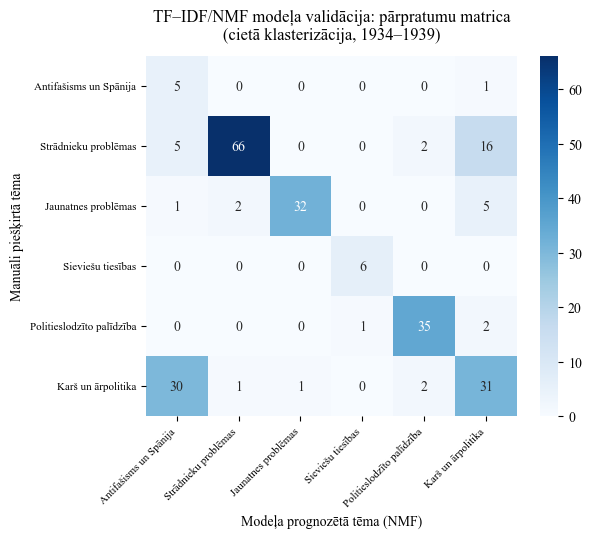

In [38]:
# ============================================================
# 13. PĀRPRATUMU MATRICA — GRAFIKS
# ============================================================

fig, ax = plt.subplots(figsize=FIGSIZE_THESIS)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 10},
    ax=ax,
    cbar=True
)

ax.set_title(
    "TF–IDF/NMF modeļa validācija: pārpratumu matrica\n"
    "(cietā klasterizācija, 1934–1939)",
    fontsize=12,
    pad=12
)

ax.set_xlabel("Modeļa prognozētā tēma (NMF)", fontsize=10)
ax.set_ylabel("Manuāli piešķirtā tēma", fontsize=10)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()

conf_png, conf_svg = save_figure(fig, "01_confusion_matrix_validation", out_dir=out_dir)

plt.show()

Saglabāts: /content/output/05_soft_clustering_relative_share_1934_1939.png
Saglabāts: /content/output/05_soft_clustering_relative_share_1934_1939.svg


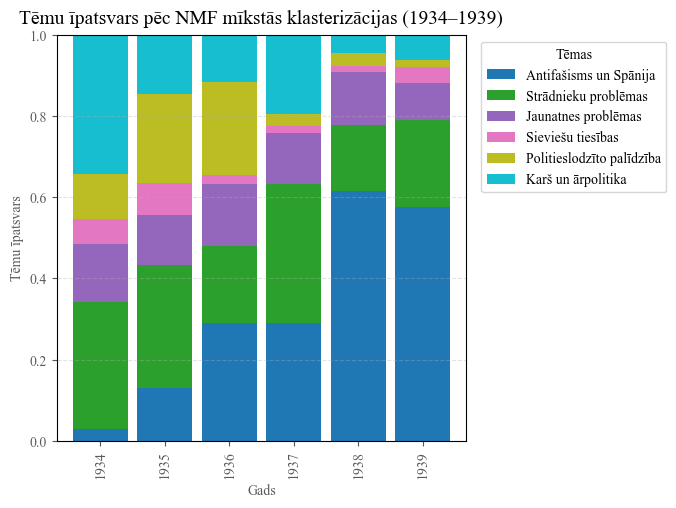

Saglabāts: /content/output/06_soft_clustering_absolute_intensity_1934_1939.png
Saglabāts: /content/output/06_soft_clustering_absolute_intensity_1934_1939.svg


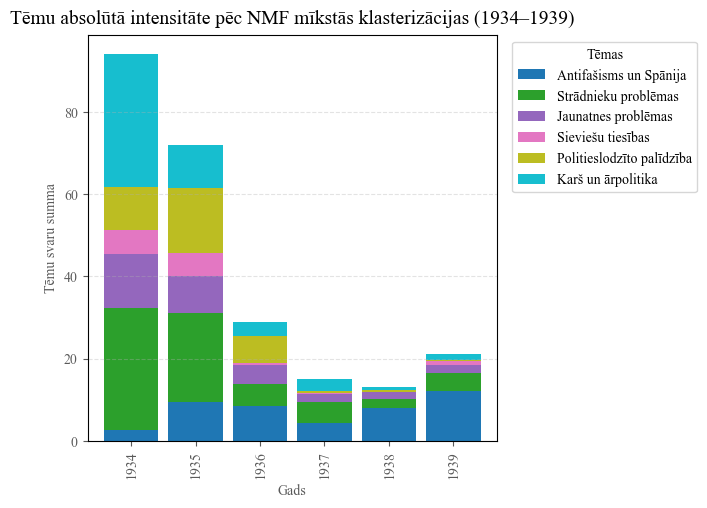

In [39]:
# ============================================================
# 14. GALVENIE NMF GRAFIKI
# ============================================================

# -----------------------
# 14.1. Relatīvais īpatsvars — soft clustering
# -----------------------

fig, ax = plt.subplots(figsize=FIGSIZE_THESIS)

soft_clustering_relative.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="tab10",
    width=0.85,
    edgecolor="none"
)

clean_axes_style(
    ax,
    title="Tēmu īpatsvars pēc NMF mīkstās klasterizācijas (1934–1939)",
    xlabel="Gads",
    ylabel="Tēmu īpatsvars"
)

ax.set_ylim(0, 1)
ax.set_xticklabels([str(y) for y in TARGET_YEARS], rotation=90)

clean_legend(ax, title="Tēmas")

fig.subplots_adjust(
    left=0.10,
    right=0.75,
    bottom=0.14,
    top=0.88
)

soft_rel_png, soft_rel_svg = save_figure(
    fig,
    "05_soft_clustering_relative_share_1934_1939",
    out_dir=out_dir
)

plt.show()


# -----------------------
# 14.2. Absolūtā intensitāte — soft clustering
# -----------------------

fig, ax = plt.subplots(figsize=FIGSIZE_THESIS)

soft_clustering_absolute.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="tab10",
    width=0.85,
    edgecolor="none"
)

clean_axes_style(
    ax,
    title="Tēmu absolūtā intensitāte pēc NMF mīkstās klasterizācijas (1934–1939)",
    xlabel="Gads",
    ylabel="Tēmu svaru summa"
)

ax.set_xticklabels([str(y) for y in TARGET_YEARS], rotation=90)

clean_legend(ax, title="Tēmas")

fig.subplots_adjust(
    left=0.10,
    right=0.75,
    bottom=0.14,
    top=0.88
)

soft_abs_png, soft_abs_svg = save_figure(
    fig,
    "06_soft_clustering_absolute_intensity_1934_1939",
    out_dir=out_dir
)

plt.show()

In [40]:
# ============================================================
# 15. MANUĀLĀ VS NMF CIETĀ KLASIFIKĀCIJA — EXCEL TABULA
# ============================================================

# NMF cietā klasifikācija
nmf_for_grouped_chart = (
    nmf_hard_counts_by_year
    .reset_index()
    .rename(columns={"year": "Gads"})
)

nmf_for_grouped_chart.insert(1, "Metode", "NMF")

# Manuālā cietā klasifikācija bez "Cits",
# lai salīdzinājums būtu ar 6 NMF tēmām
manual_for_grouped_chart = (
    manual_counts_by_year[topic_order]
    .reset_index()
    .rename(columns={"year": "Gads"})
)

manual_for_grouped_chart.insert(1, "Metode", "Manuāla")

grouped_stacked_input = pd.concat(
    [manual_for_grouped_chart, nmf_for_grouped_chart],
    ignore_index=True
)

method_order = pd.CategoricalDtype(["Manuāla", "NMF"], ordered=True)
grouped_stacked_input["Metode"] = grouped_stacked_input["Metode"].astype(method_order)
grouped_stacked_input = grouped_stacked_input.sort_values(["Gads", "Metode"])

grouped_chart_path = f"{out_dir}/manual_vs_nmf_grouped_stacked_bar_input.xlsx"

grouped_stacked_input.to_excel(grouped_chart_path, index=False)

display(grouped_stacked_input)

print("Saglabāts:", grouped_chart_path)

,Gads,Metode,Antifašisms un Spānija,Strādnieku problēmas,Jaunatnes problēmas,Sieviešu tiesības,Politieslodzīto palīdzība,Karš un ārpolitika
0,1934,Manuāla,0,41,19,2,14,18
6,1934,NMF,1,28,14,3,12,36
1,1935,Manuāla,0,27,8,4,19,14
7,1935,NMF,6,23,8,4,21,10
2,1936,Manuāla,5,8,5,0,5,6
8,1936,NMF,9,6,4,0,6,4
3,1937,Manuāla,1,5,3,0,0,6
9,1937,NMF,2,6,2,0,0,5
4,1938,Manuāla,0,2,3,0,0,8
10,1938,NMF,9,1,3,0,0,0


Saglabāts: /content/output/manual_vs_nmf_grouped_stacked_bar_input.xlsx


In [41]:
# ============================================================
# 16. KORPUSA STATISTIKA — VIENS PATIESĪBAS AVOTS
# ============================================================

assert len(df) == W.shape[0], (
    f"NESAKRITĪBA: df satur {len(df)} dokumentus, bet W matrica satur {W.shape[0]} rindas."
)

print(f"Korpusa konsistence apstiprināta: {len(df)} dokumenti gan df, gan W matricā.")

# LCLC saderīgs raw vārdu regex
LCLC_WORD_RE = re.compile(r"\b[\w'’\-]+\b", flags=re.UNICODE)

def extract_text_body_lclc(raw_text):
    s = str(raw_text)

    m = re.search(r"(?im)^\s*text:\s*\n", s)
    if m:
        return s[m.end():].strip()

    m = re.search(r"(?im)\btext:\s*(.*)", s, flags=re.DOTALL)
    if m:
        return m.group(1).strip()

    return s.strip()

def count_raw_words_lclc(raw_text):
    text_body = extract_text_body_lclc(raw_text)
    return len(LCLC_WORD_RE.findall(text_body))

def count_chars_lclc(raw_text):
    text_body = extract_text_body_lclc(raw_text)
    chars_with = len(text_body)
    chars_without = len(re.sub(r"\s+", "", text_body))
    return chars_with, chars_without

df["raw_word_count_lclc"] = df["raw_text"].apply(count_raw_words_lclc)

char_results = df["raw_text"].apply(count_chars_lclc)
df["chars_with_spaces"] = char_results.apply(lambda x: x[0])
df["chars_without_spaces"] = char_results.apply(lambda x: x[1])

df["lemma_token_count"] = df["clean_text"].apply(lambda x: len(str(x).split()))

total_documents = len(df)
total_raw_words = int(df["raw_word_count_lclc"].sum())
total_chars_with = int(df["chars_with_spaces"].sum())
total_chars_without = int(df["chars_without_spaces"].sum())
total_lemma_tokens = int(df["lemma_token_count"].sum())

all_lemmas = []
for text in df["clean_text"].dropna():
    all_lemmas.extend(str(text).split())

unique_lemmas_full = len(set(all_lemmas))
nmf_vocabulary_size = len(feature_names)

avg_raw_words = df["raw_word_count_lclc"].mean()
avg_chars_with = df["chars_with_spaces"].mean()
avg_lemma_tokens = df["lemma_token_count"].mean()

definitions = pd.DataFrame([
    [
        "Raw vārds (LCLC)",
        "Vārds, kas atrasts LCLC saderīgajā Unicode regex \\b[\\w'’\\-]+\\b uz neapstrādātā teksta bloka pēc 'text:' lauka. Defisēti vārdi un apostrofi tiek skaitīti kā vienotas vienības."
    ],
    [
        "Lematizēts tokens",
        "Tokens pēc Stanza lematizācijas, POS filtra, stopvārdu izņemšanas, normalize_lemma funkcijas, garuma filtra un regex tīrīšanas."
    ],
    [
        "Unikāla lemma",
        "Atšķirīga lemma korpusā pirms TF–IDF min_df/max_df filtra."
    ],
    [
        "NMF vārdnīcas termins",
        "TF–IDF feature pēc min_df=2, max_df=0.95 un ngram_range=(1,2) filtra."
    ],
], columns=["Termins", "Definīcija"])

corpus_summary = pd.DataFrame([
    ["Dokumentu skaits korpusā", total_documents],
    ["Raw vārdu skaits (LCLC regex)", total_raw_words],
    ["Rakstzīmju skaits ar atstarpēm", total_chars_with],
    ["Rakstzīmju skaits bez atstarpēm", total_chars_without],
    ["Lematizēto tokenu skaits (NMF pipeline)", total_lemma_tokens],
    ["Unikālo lemmu skaits korpusā", unique_lemmas_full],
    ["NMF vārdnīcas izmērs pēc TF–IDF filtra", nmf_vocabulary_size],
    ["Vidējais dokumenta garums (raw vārdi)", round(avg_raw_words, 1)],
    ["Vidējais dokumenta garums (rakstzīmes ar atstarpēm)", round(avg_chars_with, 1)],
    ["Vidējais dokumenta garums (lematizētie tokeni)", round(avg_lemma_tokens, 1)],
], columns=["Rādītājs", "Vērtība"])

year_stats = (
    df.groupby("year")
    .agg(
        document_count=("file_name", "count"),
        raw_word_count=("raw_word_count_lclc", "sum"),
        chars_with_spaces=("chars_with_spaces", "sum"),
        chars_without_spaces=("chars_without_spaces", "sum"),
        lemma_token_count=("lemma_token_count", "sum"),
        avg_raw_words=("raw_word_count_lclc", "mean"),
        avg_lemma_tokens=("lemma_token_count", "mean"),
    )
    .reindex(TARGET_YEARS, fill_value=0)
)

unique_lemmas_per_year = []
for year in TARGET_YEARS:
    year_lemmas = []
    for text in df[df["year"] == year]["clean_text"].dropna():
        year_lemmas.extend(str(text).split())
    unique_lemmas_per_year.append(len(set(year_lemmas)))

year_stats["unique_lemmas"] = unique_lemmas_per_year
year_stats["avg_raw_words"] = year_stats["avg_raw_words"].round(1)
year_stats["avg_lemma_tokens"] = year_stats["avg_lemma_tokens"].round(1)

region_stats = (
    df.groupby("region_category")
    .agg(
        document_count=("file_name", "count"),
        raw_word_count=("raw_word_count_lclc", "sum"),
        chars_with_spaces=("chars_with_spaces", "sum"),
        lemma_token_count=("lemma_token_count", "sum"),
    )
)

region_stats["doc_share_pct"] = (region_stats["document_count"] / total_documents * 100).round(1)
region_stats["raw_word_share_pct"] = (region_stats["raw_word_count"] / total_raw_words * 100).round(1)
region_stats["lemma_token_share_pct"] = (region_stats["lemma_token_count"] / total_lemma_tokens * 100).round(1)

nmf_parameters = pd.DataFrame([
    ["Tēmu skaits (k)", N_TOPICS],
    ["TF–IDF vektorizators", "scikit-learn TfidfVectorizer"],
    ["N-gramma diapazons", str(TFIDF_NGRAM_RANGE)],
    ["min_df", TFIDF_MIN_DF],
    ["max_df", TFIDF_MAX_DF],
    ["NMF realizācija", "scikit-learn NMF"],
    ["NMF inicializācija", NMF_INIT],
    ["random_state", RANDOM_STATE],
    ["max_iter", NMF_MAX_ITER],
    ["W matricas normalizācija", "Katras skrejlapas tēmu svari normalizēti tā, lai summa = 1"],
    ["Klasterizācijas tips", "Mīkstā; cietā klasifikācija pēc lielākā tēmas svara"],
    ["Validācijas akurātums pret manuālo marķējumu", f"{accuracy * 100:.1f}%"],
], columns=["Parametrs", "Vērtība"])

preprocessing_steps = pd.DataFrame([
    ["1. Teksta bloka atlase", "Izvilkts teksts tikai pēc 'text:' lauka; metadati izslēgti"],
    ["2. Raw skaitīšana", "LCLC Unicode regex \\b[\\w'’\\-]+\\b uz atlasītā teksta bloka"],
    ["3. Frāžu aizvietojumi", "s.-d. → sociāldemokrāti; 1. maijs → pirmais_maijs; 7. novembris → septītais_novembris; padomju latvija → padomju_latvija; politiskā pārvalde → politiskā_pārvalde"],
    ["4. Defisētu vārdu sadalīšana", "Regex: darba-vieta → darba vieta"],
    ["5. Lematizācija", "Stanza lv: tokenize + pos + lemma"],
    ["6. POS filtrs", f"Paturēti: {', '.join(sorted(ALLOWED_POS))}"],
    ["7. Stopvārdu noņemšana", f"Latviešu stopvārdi ({len(LATVIAN_STOP_LEMMAS)}) + metadatu nosaukumi ({len(META_STOP)}) = {len(STOPWORDS)} kopā"],
    ["8. Garuma filtrs", "Tikai lemmas ar > 2 simboliem"],
    ["9. Manuālās normalizācijas", "12 prefiksu normalizācijas + 2 kļūdu labojumi"],
    ["10. Regex tīrīšana", "Tikai latviešu burti + apakšsvītras: [a-zāčēģīķļņšūž_]+"],
    ["11. TF–IDF filtrs", f"min_df={TFIDF_MIN_DF}, max_df={TFIDF_MAX_DF}, ngram_range={TFIDF_NGRAM_RANGE}"],
], columns=["Solis", "Apraksts"])

display(corpus_summary)
display(year_stats)
display(region_stats)
display(nmf_parameters)
display(preprocessing_steps)

stats_path = f"{out_dir}/corpus_statistics_reproducibility.xlsx"

with pd.ExcelWriter(stats_path, engine="openpyxl") as writer:
    definitions.to_excel(writer, sheet_name="1_definicijas", index=False)
    corpus_summary.to_excel(writer, sheet_name="2_korpuss_kopa", index=False)
    year_stats.to_excel(writer, sheet_name="3_pa_gadiem")
    region_stats.to_excel(writer, sheet_name="4_pa_regioniem")
    nmf_parameters.to_excel(writer, sheet_name="5_nmf_parametri", index=False)
    preprocessing_steps.to_excel(writer, sheet_name="6_prieksapstrade", index=False)

print("Saglabāts:", stats_path)

Korpusa konsistence apstiprināta: 244 dokumenti gan df, gan W matricā.


,Rādītājs,Vērtība
0,Dokumentu skaits korpusā,244.0
1,Raw vārdu skaits (LCLC regex),143538.0
2,Rakstzīmju skaits ar atstarpēm,1076118.0
3,Rakstzīmju skaits bez atstarpēm,931738.0
4,Lematizēto tokenu skaits (NMF pipeline),96119.0
5,Unikālo lemmu skaits korpusā,7959.0
6,NMF vārdnīcas izmērs pēc TF–IDF filtra,14324.0
7,Vidējais dokumenta garums (raw vārdi),588.3
8,Vidējais dokumenta garums (rakstzīmes ar atsta...,4410.3
9,Vidējais dokumenta garums (lematizētie tokeni),393.9


,document_count,raw_word_count,chars_with_spaces,chars_without_spaces,lemma_token_count,avg_raw_words,avg_lemma_tokens,unique_lemmas
year,,,,,,,,
1934,94,52343,395064,342451,34932,556.8,371.6,4637
1935,72,41178,310850,269429,27655,571.9,384.1,4331
1936,29,20138,150672,130366,13687,694.4,472.0,3019
1937,15,9038,65947,56841,5846,602.5,389.7,1804
1938,13,8783,64917,56083,5869,675.6,451.5,1628
1939,21,12058,88668,76568,8130,574.2,387.1,2156


,document_count,raw_word_count,chars_with_spaces,lemma_token_count,doc_share_pct,raw_word_share_pct,lemma_token_share_pct
region_category,,,,,,,
Rīga,195,119483,898606,80343,79.9,83.2,83.6
Ārpus Rīgas,49,24055,177512,15776,20.1,16.8,16.4


,Parametrs,Vērtība
0,Tēmu skaits (k),6
1,TF–IDF vektorizators,scikit-learn TfidfVectorizer
2,N-gramma diapazons,"(1, 2)"
3,min_df,2
4,max_df,0.95
5,NMF realizācija,scikit-learn NMF
6,NMF inicializācija,nndsvda
7,random_state,42
8,max_iter,1000
9,W matricas normalizācija,"Katras skrejlapas tēmu svari normalizēti tā, l..."


,Solis,Apraksts
0,1. Teksta bloka atlase,Izvilkts teksts tikai pēc 'text:' lauka; metad...
1,2. Raw skaitīšana,LCLC Unicode regex \b[\w'’\-]+\b uz atlasītā t...
2,3. Frāžu aizvietojumi,s.-d. → sociāldemokrāti; 1. maijs → pirmais_ma...
3,4. Defisētu vārdu sadalīšana,Regex: darba-vieta → darba vieta
4,5. Lematizācija,Stanza lv: tokenize + pos + lemma
5,6. POS filtrs,"Paturēti: ADJ, NOUN, PROPN, VERB"
6,7. Stopvārdu noņemšana,Latviešu stopvārdi (45) + metadatu nosaukumi (...
7,8. Garuma filtrs,Tikai lemmas ar > 2 simboliem
8,9. Manuālās normalizācijas,12 prefiksu normalizācijas + 2 kļūdu labojumi
9,10. Regex tīrīšana,Tikai latviešu burti + apakšsvītras: [a-zāčēģī...


Saglabāts: /content/output/corpus_statistics_reproducibility.xlsx


In [42]:
# ============================================================
# 17. GALA KONTROLE UN REZULTĀTU ZIP
# ============================================================

def fmt(n):
    return f"{int(n):,}".replace(",", " ")

print("=" * 80)
print("GALA KONTROLES SKAITĻI")
print("=" * 80)
print("Dokumentu skaits:", fmt(total_documents))
print("Raw vārdi:", fmt(total_raw_words))
print("Lematizētie tokeni:", fmt(total_lemma_tokens))
print("Unikālās lemmas:", fmt(unique_lemmas_full))
print("TF–IDF/NMF vārdnīca:", fmt(nmf_vocabulary_size))
print("Tēmu skaits:", N_TOPICS)
print(f"Validācijas akurātums: {accuracy * 100:.1f}%")
print("=" * 80)

summary_text = f"""
NMF modelis tika apmācīts uz visa Latvijas mēroga skrejlapu korpusu 1934.–1939. g.:
{fmt(total_documents)} dokumenti, {fmt(total_raw_words)} vārdi neapstrādātos tekstos
(skaitīti ar LCLC saderīgu Unicode regex) un {fmt(total_lemma_tokens)} lematizēti
tokeni pēc priekšapstrādes. Priekšapstrādē izmantota Stanza latviešu valodas
lematizācija, POS filtrs NOUN/VERB/ADJ/PROPN un {len(STOPWORDS)} stopvārdi.
Unikālo lemmu skaits korpusā ir {fmt(unique_lemmas_full)}. Pēc TF–IDF filtra
(min_df={TFIDF_MIN_DF}, max_df={TFIDF_MAX_DF}, ngram_range={TFIDF_NGRAM_RANGE})
NMF modeļa reālā vārdnīca satur {fmt(nmf_vocabulary_size)} terminus.
Vidējais dokumenta garums ir {avg_raw_words:.0f} vārdi un {avg_lemma_tokens:.0f}
lematizēti tokeni.
""".strip()

print("\nFORMULĒJUMS DARBAM:")
print(summary_text)

# Rezultātu sapakošana ZIP arhīvā.
# ZIP fails parādīsies Colab kreisajā Files panelī:
# /content/BA_NMF_outputs.zip

zip_output_base = "/content/BA_NMF_outputs"
zip_output_path = f"{zip_output_base}.zip"

if os.path.exists(zip_output_path):
    os.remove(zip_output_path)

shutil.make_archive(
    base_name=zip_output_base,
    format="zip",
    root_dir=OUTPUT_DIR
)

print("\nRezultāti saglabāti mapē:", OUTPUT_DIR)
print("Rezultātu ZIP:", zip_output_path)

GALA KONTROLES SKAITĻI
Dokumentu skaits: 244
Raw vārdi: 143 538
Lematizētie tokeni: 96 119
Unikālās lemmas: 7 959
TF–IDF/NMF vārdnīca: 14 324
Tēmu skaits: 6
Validācijas akurātums: 71.7%

FORMULĒJUMS DARBAM:
NMF modelis tika apmācīts uz visa Latvijas mēroga skrejlapu korpusu 1934.–1939. g.:
244 dokumenti, 143 538 vārdi neapstrādātos tekstos
(skaitīti ar LCLC saderīgu Unicode regex) un 96 119 lematizēti
tokeni pēc priekšapstrādes. Priekšapstrādē izmantota Stanza latviešu valodas
lematizācija, POS filtrs NOUN/VERB/ADJ/PROPN un 55 stopvārdi.
Unikālo lemmu skaits korpusā ir 7 959. Pēc TF–IDF filtra
(min_df=2, max_df=0.95, ngram_range=(1, 2))
NMF modeļa reālā vārdnīca satur 14 324 terminus.
Vidējais dokumenta garums ir 588 vārdi un 394
lematizēti tokeni.

Rezultāti saglabāti mapē: /content/output
Rezultātu ZIP: /content/BA_NMF_outputs.zip
